# PART A - Linear Regression

###1A- Normal Approx - Covariance Matrix

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv('/content/random_5k_rows.csv')

cols = ['MENTHLTH', '_BMI5', '_RFSMOK3', 'TOLDHI3']
df_clean = df[cols].copy().dropna()

df_clean['_BMI5'] = df_clean['_BMI5'] / 100.0

df_clean['is_smoker'] = df_clean['_RFSMOK3'].apply(lambda x: 1 if x == 2 else 0)

df_clean['has_high_chol'] = df_clean['TOLDHI3'].apply(lambda x: 1 if x == 1 else 0)

#Create the Sub-Sample of 200 [cite: 63]
np.random.seed(42)
df_sample = df_clean.sample(n=200)

# 4. Define X and Y
X_cols = ['_BMI5', 'is_smoker', 'has_high_chol']
X = df_sample[X_cols]
X = sm.add_constant(X)
y = df_sample['MENTHLTH']

# 5. Fit the Model (Part 1a)
model = sm.OLS(y, X).fit()

ci_normal_cov = model.conf_int(alpha=0.05)
ci_normal_cov.columns = ['Lower ', 'Upper ']

print("Part 1a: Confidence Intervals (Normal Approx - Covariance Matrix)")
print(ci_normal_cov)

Part 1a: Confidence Intervals (Normal Approx - Covariance Matrix)
                 Lower     Upper 
const         -4.639315  6.956475
_BMI5          0.110156  0.499578
is_smoker     -1.844629  5.210899
has_high_chol -2.907770  2.719132


###1B- Normal Approx with Bootstrap SE

In [ ]:
from scipy import stats

B = 400
n = len(df_sample)
bootstrap_betas = []

np.random.seed(42)

print(f"Running Bootstrap with B={B} iterations")

for i in range(B):

    boot_indices = np.random.choice(df_sample.index, size=n, replace=True)
    X_boot = X.loc[boot_indices]
    y_boot = y.loc[boot_indices]
    boot_model = sm.OLS(y_boot, X_boot).fit()
    bootstrap_betas.append(boot_model.params)

boot_df = pd.DataFrame(bootstrap_betas)

# Calculate Confidence Intervals
se_boot = boot_df.std()
z_score = stats.norm.ppf(0.975)

original_betas = model.params

ci_method_b = pd.DataFrame()
ci_method_b['Lower (Boot SE)'] = original_betas - (z_score * se_boot)
ci_method_b['Upper (Boot SE)'] = original_betas + (z_score * se_boot)

print("\n Part 1b Results: Normal Approx with Bootstrap SE")
print(ci_method_b)

Running Bootstrap with B=400 iterations

 Part 1b Results: Normal Approx with Bootstrap SE
               Lower (Boot SE)  Upper (Boot SE)
const                -4.633114         6.950275
_BMI5                 0.104759         0.504975
is_smoker            -1.607606         4.973876
has_high_chol        -2.830340         2.641703


###1C - Pivot method

In [ ]:
q_lower = boot_df.quantile(0.025)
q_upper = boot_df.quantile(0.975)

# Apply the Pivot Formula:
#    Lower Limit = 2*Original - Upper_Quantile
#    Upper Limit = 2*Original - Lower_Quantile
ci_pivot = pd.DataFrame()
ci_pivot['Lower (Pivot)'] = (2 * original_betas) - q_upper
ci_pivot['Upper (Pivot)'] = (2 * original_betas) - q_lower

print("Part 1c Results: Pivot Method")
print(ci_pivot)

Part 1c Results: Pivot Method
               Lower (Pivot)  Upper (Pivot)
const              -4.736120       6.977665
_BMI5               0.105762       0.503769
is_smoker          -1.876106       4.804156
has_high_chol      -2.852113       2.579158



###1D- Percentile Method

In [ ]:
ci_percentile = pd.DataFrame()
ci_percentile['Lower (Percentile)'] = q_lower
ci_percentile['Upper (Percentile)'] = q_upper

print("Part 1d Results: Percentile Method")
print(ci_percentile)

Part 1d Results: Percentile Method
               Lower (Percentile)  Upper (Percentile)
const                   -4.660505            7.053280
_BMI5                    0.105966            0.503972
is_smoker               -1.437886            5.242376
has_high_chol           -2.767796            2.663476


###2- Comparing Intervals

In [ ]:
# Fit Model on FULL Dataset
X_full = df_clean[['_BMI5', 'is_smoker', 'has_high_chol']]
X_full = sm.add_constant(X_full)
y_full = df_clean['MENTHLTH']

model_full = sm.OLS(y_full, X_full).fit()
true_betas = model_full.params

print("True Betas (from Full Dataset):")
print(true_betas)

True Betas (from Full Dataset):
const            5.814632
_BMI5            0.135297
is_smoker        4.176828
has_high_chol    0.755714
dtype: float64


In [ ]:
#Compare Intervals
results_dict = {
    '1a_Normal_Cov': ci_normal_cov,
    '1b_Boot_SE': ci_method_b,
    '1c_Pivot': ci_pivot,
    '1d_Percentile': ci_percentile
}

comparison_rows = []

for method_name, df_ci in results_dict.items():
    col_lower = df_ci.columns[0]
    col_upper = df_ci.columns[1]

    for param_name in df_ci.index:
        lower = df_ci.loc[param_name, col_lower]
        upper = df_ci.loc[param_name, col_upper]

        length = upper - lower

        # 3. Check if True Beta is Inside
        true_val = true_betas[param_name]
        is_inside = (lower <= true_val) and (true_val <= upper)

        # 4. Save to list
        comparison_rows.append({
            'Parameter': param_name,
            'Method': method_name,
            'Length': length,
            'Inside_True?': is_inside,
            'Lower': lower,
            'Upper': upper,
            'True_Beta': true_val
        })

df_comparison = pd.DataFrame(comparison_rows)

df_comparison = df_comparison.sort_values(by=['Parameter', 'Method'])

print("\n--- Question 2 Comparison Results ---")
print(df_comparison[['Parameter', 'Method', 'Length', 'Inside_True?']])


--- Question 2 Comparison Results ---
        Parameter         Method     Length  Inside_True?
1           _BMI5  1a_Normal_Cov   0.389423          True
5           _BMI5     1b_Boot_SE   0.400215          True
9           _BMI5       1c_Pivot   0.398006          True
13          _BMI5  1d_Percentile   0.398006          True
0           const  1a_Normal_Cov  11.595790          True
4           const     1b_Boot_SE  11.583389          True
8           const       1c_Pivot  11.713785          True
12          const  1d_Percentile  11.713785          True
3   has_high_chol  1a_Normal_Cov   5.626902          True
7   has_high_chol     1b_Boot_SE   5.472043          True
11  has_high_chol       1c_Pivot   5.431272          True
15  has_high_chol  1d_Percentile   5.431272          True
2       is_smoker  1a_Normal_Cov   7.055528          True
6       is_smoker     1b_Boot_SE   6.581482          True
10      is_smoker       1c_Pivot   6.680263          True
14      is_smoker  1d_Percentile 

All four methods proved valid, as every confidence interval successfully captured the true population coefficient derived from the full dataset. The standard Normal Approximation (1a) was the most precise for the continuous variable (BMI), producing the shortest interval length. In contrast, the Bootstrap methods provided narrower, more efficient intervals for the categorical variables (Smoker and Cholesterol). This suggests that while standard OLS was best for continuous data here, Bootstrap offered superior precision for the binary predictors.

###3A- Select New Data & Predict


In [ ]:

# Identify points NOT in the training sample
df_remaining = df_clean.drop(df_sample.index)

# Select 100 random points
np.random.seed(99)
df_test_100 = df_remaining.sample(n=100)

X_new = df_test_100[['_BMI5', 'is_smoker', 'has_high_chol']]
X_new = sm.add_constant(X_new)

# Predict
Y_pred = model.predict(X_new)

df_predictions_3a = pd.DataFrame({
    'Index': Y_pred.index,
    'Predicted_Mental_Health_Days': Y_pred.values
})

print("Part 3a: Predictions Table (First 5 Rows)")
print(df_predictions_3a.head())

Part 3a: Predictions Table (First 5 Rows)
   Index  Predicted_Mental_Health_Days
0   4958                     11.185850
1   4569                     10.030403
2   3826                     10.533512
3   3434                     10.137107
4    401                     12.670362


###3B - CI for Expectation $E[Y|X]$ using Bootstrap

In [ ]:
betas_matrix = boot_df.values
X_new_matrix = X_new.values
all_predictions = np.dot(X_new_matrix, betas_matrix.T)
lower_ci_exp = np.percentile(all_predictions, 2.5, axis=1)
upper_ci_exp = np.percentile(all_predictions, 97.5, axis=1)

# Create a structured DataFrame
df_results_3b = pd.DataFrame({
    'Person index': X_new.index,
    'Lower_CI_Expectation': lower_ci_exp,
    'Upper_CI_Expectation': upper_ci_exp,
    'Mean_Prediction': Y_pred.values,    # From Part 3a
    'Real_Y': Y_new_true.values })

print("Part 3b Results: Confidence Interval for Expectation (First 5 Rows")
print(df_results_3b.head())

Part 3b Results: Confidence Interval for Expectation (First 5 Rows) ---
   Person index  Lower_CI_Expectation  Upper_CI_Expectation  Mean_Prediction  \
0          4958              8.934964             13.364975        11.185850   
1          4569              7.868760             12.031310        10.030403   
2          3826              7.465263             14.104996        10.533512   
3          3434              7.982859             12.125880        10.137107   
4           401              9.786529             14.989825        12.670362   

   Real_Y  
0    30.0  
1     2.0  
2     2.0  
3     3.0  
4    10.0  


###3D- Calculating CI for $Ynew$:
To calculate the interval for a $Ynew$ , we must account for two factors of variance: the **Estimation Variance** and the **Noise Variance** (random error).
In the Bootstrap process, instead of just calculating the mean prediction, we must add a randomly sampled residual to each prediction.
This addition simulates the natural scatter of individual points around the line, effectively capturing both sources of uncertainty required for a prediction interval.
Finally, we calculate the 2.5% and 97.5% percentiles of these "noisy" predictions to obtain the interval.

# **Part 2**

## **Question 1 — Research Question**

We study whether BMI is higher among individuals who have ever been told they had a heart attack.

Our research question was if is there a statistically significant difference in the BMI between individuals who have ever been told they had a heart attack and those who have not?

We can right this question as a permutation test:

$$
\begin{aligned}
X &= \text{_BMI5} \mid \text{CVDINFR4} = 2\\
Y &= \text{_BMI5} \mid \text{CVDINFR4} = 1
\end{aligned}
$$

I.e, X is the group of people who hadn't had a heart attack, and Y is the group of people who had.

Now we can ask,
Is the BMI distribution of group X larger than that of group Y (In other words: is $X \prec Y$)?

Hypotheses (permutation-test view):
$$
H0: F_X = F_Y\\
H1: F_X \prec F_Y
$$  

## **Question 2 - Data Reload and Shape**


In [19]:
import pandas as pd
import numpy as np

path = "random_5k_rows.csv"
df = pd.read_csv(path)

research_df = df[["_BMI5", "CVDINFR4"]].dropna()
sample_df = research_df.sample(n=200, replace=False, random_state=42)

Y_pd = sample_df.loc[sample_df["CVDINFR4"] == 1, ["_BMI5"]].reset_index(drop=True)
X_pd = sample_df.loc[sample_df["CVDINFR4"] == 2, ["_BMI5"]].reset_index(drop=True)

display(Y_pd)
display(X_pd)


,_BMI5
0,2976.0
1,2356.0
2,2859.0
3,3030.0
4,2386.0
5,2755.0
6,2630.0
7,3042.0
8,2737.0
9,2187.0


,_BMI5
0,2006.0
1,2231.0
2,5081.0
3,2362.0
4,2921.0
...,...
181,2246.0
182,2507.0
183,1792.0
184,3189.0


## **Question 3 — Means Difference**

Let $\mu_1$ denote the population mean BMI among individuals with  
$\text{CVDINFR4} = 1$ (told they had a heart attack), and let $\mu_2$ denote  
the population mean BMI among individuals with  
$\text{CVDINFR4} = 2$ (not told they had a heart attack).

We define the parameter of interest as
$$
\delta_{mean} = \mu_1 - \mu_2 .
$$

### **Section a - Estimation of $δ_{mean}$**
We estimate $\mu_1$ and $\mu_2$ using the sample means from the random
subsample of size $200$:
$$
\hat{\mu}_1 = \bar{Y_m}, \qquad \hat{\mu}_2 = \bar{X_n}.
$$
While $m$ is the size of $Y$ sample and $n$ is the size of $X$ sample.
Accordingly, the estimator of $\delta$ is
$$
\hat{\delta}_{mean} = \hat{\mu}_1 - \hat{\mu}_2 = \bar{Y_m} - \bar{X_n}.
$$


In [37]:
# NumPy arrays (for ALL computations)
Y = Y_pd.to_numpy()
X = X_pd.to_numpy()

# sample sizes
m = Y.shape[0]   # size of Y sample
n = X.shape[0]   # size of X sample

# estimators
Y_bar_m = Y.mean()
X_bar_n = X.mean()

delta_hat_mean = Y_bar_m - X_bar_n

print(f"m = {m}, n = {n}")
print(f"Ȳ_m (μ̂₁) = {Y_bar_m:.4f}")
print(f"X̄_n (μ̂₂) = {X_bar_n:.4f}")
print(f"δ̂ _mean= Ȳ_m − X̄_n = {delta_hat:.4f}")


m = 14, n = 186
Ȳ_m (μ̂₁) = 2689.0000
X̄_n (μ̂₂) = 2920.9785
δ̂ _mean= Ȳ_m − X̄_n = -79.0000


#### **3a - Results**

From the random subsample of size $200$ we obtained:
- $m = 14$ observations in the heart-attack group ($Y$)
- $n = 186$ observations in the no-heart-attack group ($X$).

Numerically (based on the current subsample):
- $\hat{\mu}_1 = 2689.00$
- $\hat{\mu}_2 = 2920.97$
- $\hat{\delta}_{mean} = -231.97$

The estimate $\hat{\delta}$ came out negative. We are estimate that is because in this particular random subsample the sample mean BMI in the heart-attack group was smaller than the sample mean BMI in the no-heart-attack group, i.e. $\bar{Y} < \bar{X}$. This is plausible here since the heart-attack group is very small ($m=14$), so $\bar{Y}$ (and therefore $\hat{\delta}$) has high sampling variability.

**Is $\hat{\delta}_{mean}$ an MLE?**  
Under the assumption that the data distributes normally,
$\hat{\delta}_{mean}$ is a maximum likelihood estimator.
That because in such case,
$\hat{\mu}_1=\bar{Y}$ and $\hat{\mu}_2=\bar{X}$ are the MLEs of $\mu_1,\mu_2$, and
consequently $\hat{\delta}_{mean}=\bar{Y}-\bar{X}$ is the MLE of
$\delta_{mean}=\mu_1-\mu_2$.

### **Section b - CI for $\delta_{mean}$**
Assuming a parametric model under which the estimator
$\hat{\delta}_{mean}$ is a maximum likelihood estimator,
it follows that $\hat{\delta}_{mean}$ is asymptotically normal.

Therefore,
$$
\sqrt{n}\,(\hat{\delta}_{mean}-\delta_{mean})\ \xrightarrow{d}\ \mathcal{N}(0,\,\sigma^2)
$$

and an approximate $(1-\alpha)$ confidence interval for $\delta$ is given by:

$$
\hat{\delta}_{mean} \pm z_{1-\alpha/2}\cdot
\sqrt{\frac{S_Y^2}{m}+\frac{S_X^2}{n}}
$$

where $S_Y^2$ and $S_X^2$ are the sample variances of the two groups.


In [39]:
from scipy.stats import norm

# sample sizes
m = Y.shape[0]
n = X.shape[0]

# sample means (scalars)
Y_bar = float(Y.mean())
X_bar = float(X.mean())
delta_hat_mean = Y_bar - X_bar

# sample variances
SY2 = Y.var(ddof=1)
SX2 = X.var(ddof=1)

# standard error
SE = np.sqrt(SY2/m + SX2/n)

# confidence level
alpha = 0.05
z = norm.ppf(1 - alpha/2)

# confidence interval
CI_low = delta_hat_mean - z * SE
CI_high = delta_hat_mean + z * SE

print(f"95% CI for delta = ({CI_low:.4f}, {CI_high:.4f})")


95% CI for delta = (-409.6473, -54.3097)


#### **3b - Results**
The 95% confidence interval for $\delta$ is: $[-409.65,\,-54.31]$

### **Section c - Full Data Estimator**
Let $\hat{\delta}_{\text{full}}$ denote the estimator computed from all available observations.

In [40]:
Y_full = research_df.loc[research_df["CVDINFR4"] == 1, "_BMI5"].to_numpy()
X_full = research_df.loc[research_df["CVDINFR4"] == 2, "_BMI5"].to_numpy()

delta_hat_mean_full = Y_full.mean() - X_full.mean()

print(f"delta_hat (full data) = {delta_hat_mean_full:.4f}")
print("Is delta_hat(full) inside the CI?",
      CI_low <= delta_hat_mean_full <= CI_high)


delta_hat (full data) = 49.5044
Is delta_hat(full) inside the CI? False


#### **3c - Results**
Using the full dataset, we obtain $\hat{\delta}_{mean (full)} = 49.50$.
This value does not lie within the 95% confidence interval computed from the
random subsample, indicating inconsistency between the subsample-based interval
and the full-data estimate, likely due to sampling variability in the small
heart-attack group of the subsample.


### **Section d - Hypothesis Testing**

We test the hypothesis formulated in Question 1 using two approaches:
a Wald test based on asymptotic normality, and a permutation test. In both cases we consider a one-sided alternative.

We note that Both tests are based on the estimator $\hat{\delta}_{mean}$ computed
from the random subsample of size 200.



#### **Wald's Test**

We test
$$
H_0:\ \delta_{mean} = 0
\qquad \text{vs.} \qquad
H_1:\ \delta_{mean} > 0,
$$

The Wald statistic is,
$$
W = \frac{\hat{\delta}_{mean}}{\sqrt{\frac{S_Y^2}{m}+\frac{S_X^2}{n}}},
$$
which is approximately standard normal under $H_0$.


In [47]:
# Wald statistic
W_mean = delta_hat_mean / SE

# one-sided p-value for H1: delta > 0
p_wald_mean = 1 - norm.cdf(W)

# Results
print(f"W_mean = {W:.4f}")
print(f"p_wald_mean = {p_wald:.4f}")


W_mean = -2.5591
p_wald_mean = 0.9948


**Wald test result**

The Wald test yields a test statistic $W=-2.56$ with a one-sided p-value of $0.9948$.

Therefore, at any reasonable significance level, particular in 5% we fail to reject the null hypothesis $H_0:\delta=0$.


#### **Permutation test (based on the difference in means)**

We test
$$
H_0:\ F_X = F_Y
\\
H_1:\ X \prec Y
$$

i.e., the BMI distribution in the heart-attack group ($Y$) is stochastically
larger than in the no–heart-attack group ($X$).

We use the test statistic (difference in sample means)
$$
T = \bar{Y_m} - \bar{X_n} = \hat{\delta}_{mean}
$$

Since In our data, $m=14$ and $n=186$, so the exact permutation test would require
evaluating $\binom{200}{14} \approx 6\times10^{20}$ permutations, which is
computationally infeasible. Therefore, we use a Monte Carlo approximation for the permutation distribution using random sampling.


Now,

$$
p_{value} = \frac{1}{B}\sum_{b=1}^B \mathbf{1}\{T^{(b)} \ge T_{\text{obs}}\}.
$$

While $B$ is the number of random samples.

We will reject $H_0$ if $p_{value} < α = 0.05$.



In [48]:
# Observed statistic
T_obs = delta_hat_mean

# Number of permutations (theoretical total is comb(n+m, n), but we approximate)

# Permutation parameters
B = 400
pooled = np.concatenate([X, Y])
N = pooled.size #(m+n)

perm_stats = np.empty(B, dtype=float)
rng = np.random.default_rng(42)

for b in range(B):
    perm = rng.permutation(pooled)
    Y_perm = perm[m:]      # keep group sizes fixed: |X|=m, |Y|=n
    X_perm = perm[:m]
    perm_stats[b] = Y_perm.mean() - X_perm.mean()

# One-sided p-value for H1: delta > 0
p_peramutation_mean = np.mean(perm_stats >= T_obs)

alpha = 0.05
reject = (p_value <= alpha)

print(f"T_obs = {T_obs:.4f}")
print(f"p_peramutation_mean = {p_value:.4f}")
print("Reject H0?" , reject)


T_obs = -231.9785
p_peramutation_mean = 0.8525
Reject H0? False


**Permutation test result (difference in means)**

The permutation test based on the difference in sample means yields
$T_{\text{obs}} = -231.98$ with a one-sided $p_{value} = 0.852$.

At the $5$% significance level, we fail to reject the null hypothesis $H_0$.

## **Question 4 — Medians Difference**

Let $m_1$ denote the population median BMI among individuals with  
$\text{CVDINFR4} = 1$ (told they had a heart attack), and let $m_2$ denote  
the population median BMI among individuals with  
$\text{CVDINFR4} = 2$ (not told they had a heart attack).

We define the parameter of interest as
$$
\delta_{median} = m_1 - m_2 .
$$

### **Section a – Estimation of $\delta_{median}$**

We estimate $m_1$ and $m_2$ using the sample medians from the random subsample
of size 200.

Let $\tilde{Y}$ and $\tilde{X}$ denote the sample medians of the
heart-attack group and the no–heart-attack group, respectively.

Accordingly, the estimator of $\delta$ is
$$
\hat{\delta}_{median} = \tilde{Y} - \tilde{X}.
$$


In [44]:
# estimators: sample medians
Y_tilde = np.median(Y)
X_tilde = np.median(X)

delta_hat_median = Y_tilde - X_tilde

print(f"m = {m}, n = {n}")
print(f"Median of Y (m1) = {Y_tilde:.4f}")
print(f"Median of X (m2) = {X_tilde:.4f}")
print(f"δ̂ = m1 − m2 = {delta_hat_median:.4f}")

m = 14, n = 186
Median of Y (m1) = 2746.0000
Median of X (m2) = 2825.0000
δ̂ = m1 − m2 = -79.0000


#### **4a – Results**

We obtain:
- $\hat{m}_1 = 2746$
- $\hat{m}_2 = 2825$
- $\hat{\delta}_{median} = -79$

Again, we obtain a negative estimator, which does not support our research
hypothesis. This is likely due to sampling variability, especially given the
small size of the heart-attack group.

The sample median is generally not a MLE even we assume normal distribution (we already saw that is the mean).



### **Section b - Bootstrap CI for $\delta_{median}$**

We generate bootstrap samples,

$$
Y^{*(b)} = (Y^{*(b)}_1,\dots,Y^{*(b)}_m), \qquad
X^{*(b)} = (X^{*(b)}_1,\dots,X^{*(b)}_n), \quad b=1,\dots,B
$$

by sampling with replacement from $Y$ and $X$, respectively, and compute

$$
\hat{\delta}_{median}^{*(b)} = \tilde Y^{*(b)} - \tilde X^{*(b)}
$$

A $(1-\alpha)$ percentile bootstrap confidence interval for $\delta$ is given by

$$
\left[
q_{\alpha/2}\left(\hat{\delta}_{median}^*\right),\;
q_{1-\alpha/2}\left(\hat{\delta}_{median}^*\right)
\right]
$$
where $q_p(\cdot)$ denotes the $p$-th empirical quantile of the bootstrap distribution.


In [45]:
rng = np.random.default_rng(42)

# Bootstrap estimates: δ̂* = median(Y*) - median(X*)
delta_star = np.empty(B, dtype=float)

for b in range(B):
    Y_star = rng.choice(Y, size=Y.shape[0], replace=True)
    X_star = rng.choice(X, size=X.shape[0], replace=True)
    delta_star[b] = np.median(Y_star) - np.median(X_star)

# Percentile bootstrap CI: [ q_{α/2}(δ̂*), q_{1-α/2}(δ̂*) ]
CI_low = np.quantile(delta_star, alpha/2)
CI_high = np.quantile(delta_star, 1 - alpha/2)

print(f"Bootstrap 95% CI for delta (medians) = ({CI_low:.4f}, {CI_high:.4f})")


Bootstrap 95% CI for delta (medians) = (-412.1000, 161.5125)


**4b - Result**

The 95% bootstrap confidence interval for the difference in medians ($δ_{meadian}$) is
$[-412.10,\;161.51]$.


### **Section c - Full Data Estimator**
Let $\hat{\delta}_{median(full)}$ denote the estimator computed from all available observations.

In [46]:
delta_hat_median_full = Y_full.mean() - X_full.mean()

print(f"delta_hat (full data) = {delta_hat_median_full:.4f}")
print("Is delta_hat(full) inside the CI?",
      CI_low <= delta_hat_median_full <= CI_high)


delta_hat (full data) = 49.5044
Is delta_hat(full) inside the CI? True


#### **3c - Results**
We obtain $\hat{\delta}_{median (full)} = 49.50$.
This value does within the 95% confidence interval computed before.

This indicates consistency between the full-data estimate and the bootstrap
confidence interval.



### **Section d - Permutation Test**

We are testing the hypothesis formulated in Question 1 using permutation tests.

Now,

$$
T =  \tilde{Y} - \tilde{X} = \hat{\delta}_{median}
$$

and all remains the same as at $Q3d$.



In [50]:
# Observed statistic
T_obs = delta_hat_median

# Number of permutations (theoretical total is comb(n+m, n), but we approximate)

# Permutation parameters
B = 400
pooled = np.concatenate([X, Y])
N = pooled.size #(m+n)

perm_stats = np.empty(B, dtype=float)
rng = np.random.default_rng(42)

for b in range(B):
    perm = rng.permutation(pooled)
    Y_perm = perm[m:]      # keep group sizes fixed: |X|=m, |Y|=n
    X_perm = perm[:m]
    perm_stats[b] = np.median(Y_perm) - np.median(X_perm)

# One-sided p-value for H1: delta > 0
p_permutation_meadin = np.median(perm_stats >= T_obs)

reject = (p_value <= alpha)

print(f"T_obs = {T_obs:.4f}")
print(f"p_permutation_meadin = {p_value:.4f}")
print("Reject H0?" , reject)


T_obs = -79.0000
p_permutation_meadin = 0.8525
Reject H0? False


**4d - Permutation test result (difference in means)**

The permutation test based on the difference in sample means yields
$T_{\text{obs}} = -79$ with a one-sided $p_{value} = 0.852$.

At the $5$% significance level, we fail to reject the null hypothesis $H_0$.

### **4e - Choice of test**

**Wald test**  
A Wald test is not appropriate here since the estimator of the difference in
medians does not admit a simple asymptotic normal distribution with a known
standard error. Therefore, the assumptions underlying the Wald test are not
satisfied.

**t-test**  
A t-test is also unsuitable because it is designed for inference on differences
in means, not medians, and relies on parametric assumptions that do not hold for
the sample median.


#### **Permutation test (based on rank-sum statistic)**

We test
$$
H_0:\ F_X = F_Y
\\
H_1:\ F_X < F_Y
$$

let $S^(1),\dots,S^(m)$ be the ranks of $Y_1,\dots,Y_m$ in the joint sample.

Denote , $S_1 = \sum_{j=1}^{m} S^(j)$

We use the rank-sum test statistic
$$
T = S_1
$$

Since In our data, $m=14$ and $n=186$, so the exact permutation test would require
evaluating $\binom{200}{14} \approx 6\times10^{20}$ permutations, which is
computationally infeasible. Therefore, we use a Monte Carlo approximation for the permutation distribution using random sampling.


Now,

$$
p_{value} = \frac{1}{B}\sum_{b=1}^B \mathbf{1}\{T^{(b)} \ge T_{\text{obs}}\}.
$$

While $B$ is the number of random samples.

We will reject $H_0$ if $p_{value} < α = 0.05$.


### Question 5 – Permutation test based on rank-sum statistic

Let $S_1$ denote the sum of the ranks of the observations in the first group
(individuals with CVDINFR4 = 1) within the joint sample.
We test the hypothesis formulated in Question 1 using a permutation test with
test statistic
$$
T = S_1.
$$

Under the null hypothesis $H_0: F_X = F_Y$, the group labels are exchangeable.
Since the total number of permutations $\binom{n+m}{m}$ is computationally
infeasible, we approximate the permutation distribution using Monte Carlo
sampling and compute the p-value accordingly.


## **Question 5 - Permutation Rank-sum test**
### **Normal approximation vs. Monte Carlo permutation**

We test
$$
H_0:\ F_X = F_Y,
\qquad
H_1:\ F_X < F_Y.
$$

Let $S^{(1)},\dots,S^{(m)}$ be the ranks of $Y_1,\dots,Y_m$ in the joint sample,
and define the rank-sum statistic
$$
S_1=\sum_{j=1}^m S^{(j)}.
$$

Note that we can use the normal approximation because the sample of $Y$ is generally considered to be large enough (>30).

So we will compute the p-value in two ways and compare:

**(1) Normal approximation (no sampling).**  
Under $H_0$ (and for large samples), $S_1$ has an approximately normal
distribution with
$$
\mathbb{E}[S_1]=\frac{m(m+n+1)}{2}, \qquad
\mathrm{Var}(S_1)=\frac{mn(m+n+1)}{12},
$$
(ignoring ties). Therefore,
$$
Z=\frac{S_{1,\text{obs}}-\mathbb{E}[S_1]}{\sqrt{\mathrm{Var}(S_1)}}\approx\mathcal{N}(0,1),
$$
and we compute a one-sided p-value from the standard normal tail.

**(2) Monte Carlo permutation test (sampling).**  
Since enumerating all $\binom{m+n}{m}$ permutations is infeasible, we approximate
the permutation distribution by drawing $B$ random permutations and estimate
$$
p_{\text{perm}}=\frac{1}{B}\sum_{b=1}^B \mathbf{1}\{S_1^{(b)}\ge S_{1,\text{obs}}\}.
$$

Finally, we compare the two p-values and check whether they lead to the same
decision at $\alpha=0.05$.


In [52]:

N = n + m

# ---------- observed rank-sum S1 (sum of ranks of Y in the pooled sample) ----------
Z = np.concatenate([X, Y])
Z = Z.ravel()

# ranks with tie-handling (average ranks)
order = np.argsort(Z, kind="mergesort")
ranks = np.empty(N, dtype=float)
ranks[order] = np.arange(1, N + 1, dtype=float)

sorted_Z = Z[order]
start = 0
while start < N:
    end = start
    while end + 1 < N and sorted_Z[end + 1] == sorted_Z[start]:
        end += 1
    if end > start:
        avg_rank = (start + 1 + end + 1) / 2.0
        ranks[order[start:end + 1]] = avg_rank
    start = end + 1

S1_obs = ranks[n:].sum()   # Y is the last m entries

# ---------- (1) Normal approximation for rank-sum ----------
# Mean under H0
E_S1 = m * (N + 1) / 2

# Variance under H0 with tie correction:
# Var = (mn/12) * ( (N+1) - sum_k (t_k^3 - t_k)/(N*(N-1)) )
# where t_k are tie group sizes in the pooled sample.
vals, counts = np.unique(Z, return_counts=True)
tie_term = np.sum(counts**3 - counts)
Var_S1 = (m * n / 12) * ((N + 1) - tie_term / (N * (N - 1)))

Z_obs = (S1_obs - E_S1) / np.sqrt(Var_S1)

# one-sided p-value: large S1 supports H1: F_X < F_Y
p_normal = 1 - norm.cdf(Z_obs)

# ---------- (2) Monte Carlo permutation test ----------
rng = np.random.default_rng(42)

perm_stats = np.empty(B, dtype=float)
for b in range(B):
    perm_idx = rng.permutation(N)
    Y_idx = perm_idx[n:]          # keep group sizes fixed (size m)
    perm_stats[b] = ranks[Y_idx].sum()

p_perm = np.mean(perm_stats >= S1_obs)

# ---------- decision ----------
print(f"m={m}, n={n}, N={N}")
print(f"S1_obs = {S1_obs:.4f}")
print(f"Normal approx: Z = {Z_obs:.4f}, p = {p_normal:.4f}, reject? {p_normal <= alpha}")
print(f"Permutation MC: p = {p_perm:.4f}, reject? {p_perm <= alpha}")


m=14, n=186, N=200
S1_obs = 1190.5000
Normal approx: Z = -1.0367, p = 0.8501, reject? False
Permutation MC: p = 0.8482, reject? False


**Q5 - Results**

The observed rank-sum statistic is $S_{1,\text{obs}} = 1190.5$.

Using the normal approximation, we obtain $Z = -1.0367$ with a one-sided
$p$-value of $0.8501$.

The Monte Carlo permutation test yields a similar
$p$-value of $0.8482$.
At the 5% significance level, both approaches lead to the same

**conclusion:**
we fail to reject the null hypothesis $H_0: F_X = F_Y$.


## **Question 6 - Results Discussion**

All statistical tests performed in Questions 3–5 failed to reject the null
hypothesis. This holds across different parameters and methods, including
differences in means, medians, and rank-based statistics.

Both parametric and nonparametric approaches yielded consistent results, with
p-values above the 5% significance level.



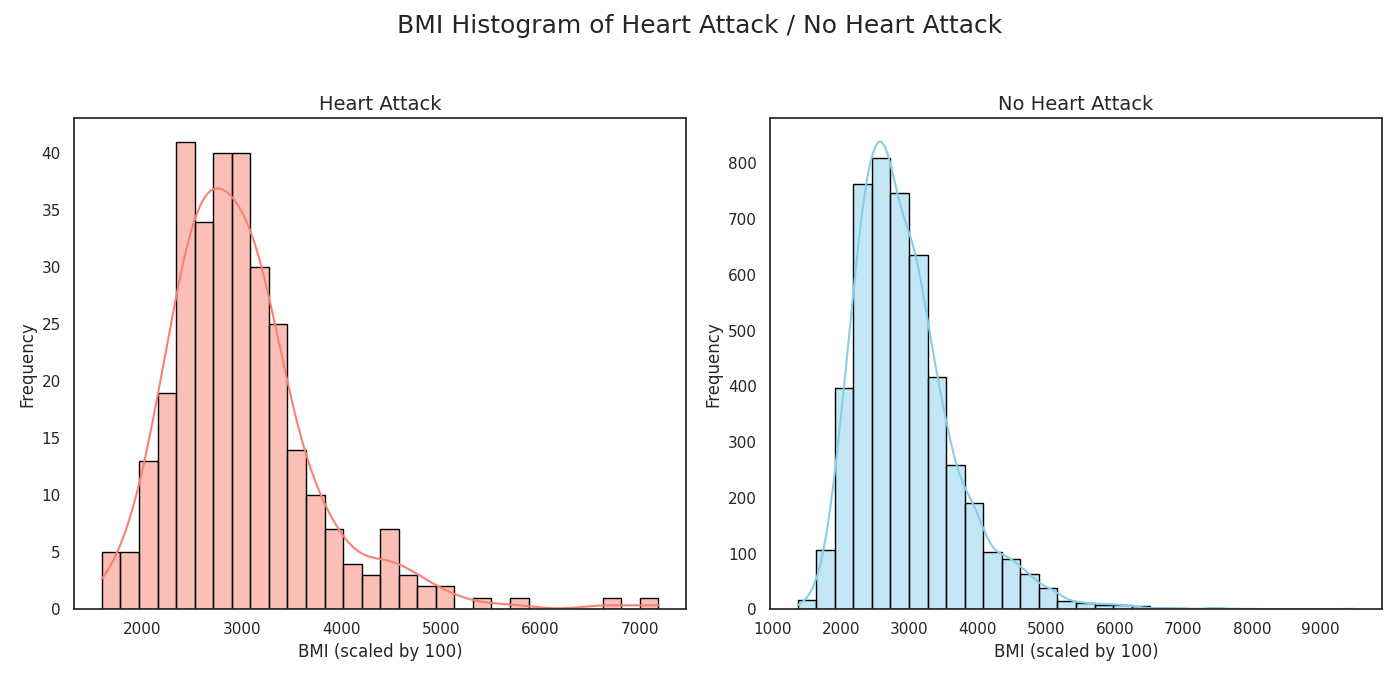

Also the histograms show that the BMI distributions of people who had heart attack and people who hadn't are very
similar, which is consistent with the statistical tests failing to reject the null hypothesis.

Overall, the findings provide no evidence that individuals who experienced
a heart attack have a higher BMI than those who did not.

For conclusion, from our research, we can assume that High BMI rate dosnet necceserly cause to heart attack.
